In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"]=[15,10]
pd.set_option("display.max_columns",100)

In [4]:

train = pd.read_csv("train_qWM28Yl.csv")
train.head()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,gear_box,steering_type,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K12N Dualjet,2,Yes,Yes,No,Yes,Yes,Drum,1197,4,Automatic,5,Electric,4.8,3995,1735,1515,1335,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,2,No,No,No,No,Yes,Drum,999,3,Automatic,5,Electric,5.0,3731,1579,1490,1155,No,No,No,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


In [189]:
test = pd.read_csv("test_zo1G9sv.csv")
test.head()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,gear_box,steering_type,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating
0,ID58593,0.341732,0.00,0.586538,C3,4076,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0
1,ID58594,0.307241,0.13,0.442308,C8,8794,1,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,K Series Dual jet,2,No,Yes,No,Yes,No,Drum,1197,4,Manual,5,Electric,4.8,3845,1735,1530,1335,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2
2,ID58595,0.327924,0.12,0.451923,C8,8794,2,A,M3,Petrol,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,2,No,No,No,No,Yes,Drum,999,3,Automatic,5,Electric,5.0,3731,1579,1490,1155,No,No,No,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2
3,ID58596,0.782654,0.01,0.461538,C5,34738,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0
4,ID58597,1.233404,0.02,0.634615,C5,34738,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0


In [7]:
train.shape, test.shape

((58592, 44), (39063, 43))

In [9]:
test.isnull().sum()

policy_id                           0
policy_tenure                       0
age_of_car                          0
age_of_policyholder                 0
area_cluster                        0
population_density                  0
make                                0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
gear_box                            0
steering_type                       0
turning_radius                      0
length      

In [12]:
train.skew()

policy_tenure          0.053588
age_of_car             1.094081
age_of_policyholder    0.640049
population_density     1.674178
make                   1.197457
airbags                0.905946
displacement          -0.105317
cylinder              -0.525074
gear_box               1.183054
turning_radius         0.420983
length                 0.145801
width                 -0.488392
height                 1.035498
gross_weight           0.546949
ncap_rating            0.085147
is_claim               3.563967
dtype: float64

In [15]:

samplex = train.drop(["policy_id","max_torque","max_power","is_claim"],axis =1)
y  =train.is_claim

In [18]:
inputx = pd.get_dummies(samplex, drop_first=True)

In [11]:
from sklearn.ensemble import RandomForestClassifier


In [19]:
rf = RandomForestClassifier()
rf.fit(inputx,y)

RandomForestClassifier()

<AxesSubplot:>

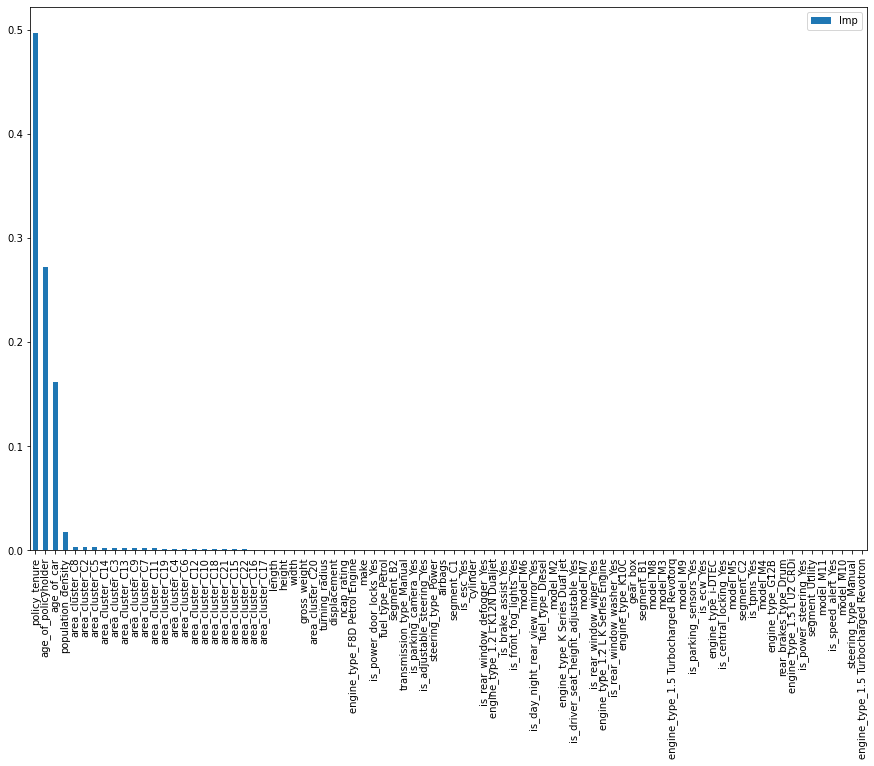

In [27]:
pd.DataFrame(rf.feature_importances_,index = inputx.columns,columns=["Imp"]).sort_values("Imp",ascending = False).plot(kind = "bar")

In [28]:
# Univariate Analysis

In [29]:
combined = pd.concat([train,test],ignore_index = True)

In [33]:
combined.shape

(97655, 44)

In [34]:
combined["ncap_rating"] =combined.ncap_rating.astype("object")

In [35]:
combined["cylinder"] =combined.cylinder.astype("object")

In [42]:
combined["gear_box"] =combined.gear_box.astype("object")

In [48]:
combined["make"] = combined.make.astype("object")

In [51]:
combined

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,gear_box,steering_type,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.60,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0.0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.60,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0.0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.60,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0.0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K12N Dualjet,2,Yes,Yes,No,Yes,Yes,Drum,1197,4,Automatic,5,Electric,4.80,3995,1735,1515,1335,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0.0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,2,No,No,No,No,Yes,Drum,999,3,Automatic,5,Electric,5.00,3731,1579,1490,1155,No,No,No,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97650,ID97651,0.047982,0.15,0.740385,C2,27003,1,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,K Series Dual jet,2,No,Yes,No,Yes,No,Drum,1197,4,Manual,5,Electric,4.80,3845,1735,1530,1335,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,NaN
97651,ID97652,1.224838,0.05,0.509615,C8,8794,3,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,6,Power,5.20,4300,1790,1635,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,NaN
97652,ID97653,0.520287,0.12,0.355769,C6,13051,1,B2,M7,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K Series Engine,6,Yes,Yes,No,Yes,Yes,Drum,1197,4,Automatic,5,Electric,4.85,3990,1745,1500,1410,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,0,NaN
97653,ID97654,1.172391,0.08,0.644231,C5,34738,1,C1,M2,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K12N Dualjet,2,Yes,Yes,No,Yes,Yes,Drum,1197,4,Automatic,5,Electric,4.80,3995,1735,1515,1335,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,NaN


In [54]:
combined.select_dtypes(object).columns

Index(['policy_id', 'area_cluster', 'make', 'segment', 'model', 'fuel_type',
       'max_torque', 'max_power', 'engine_type', 'is_esc',
       'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'cylinder',
       'transmission_type', 'gear_box', 'steering_type', 'is_front_fog_lights',
       'is_rear_window_wiper', 'is_rear_window_washer',
       'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating'],
      dtype='object')

In [59]:
cat_cols = ['make','fuel_type','is_esc',
       'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'cylinder',
       'transmission_type', 'gear_box', 'steering_type', 'is_front_fog_lights',
       'is_rear_window_wiper', 'is_rear_window_washer',
       'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating']

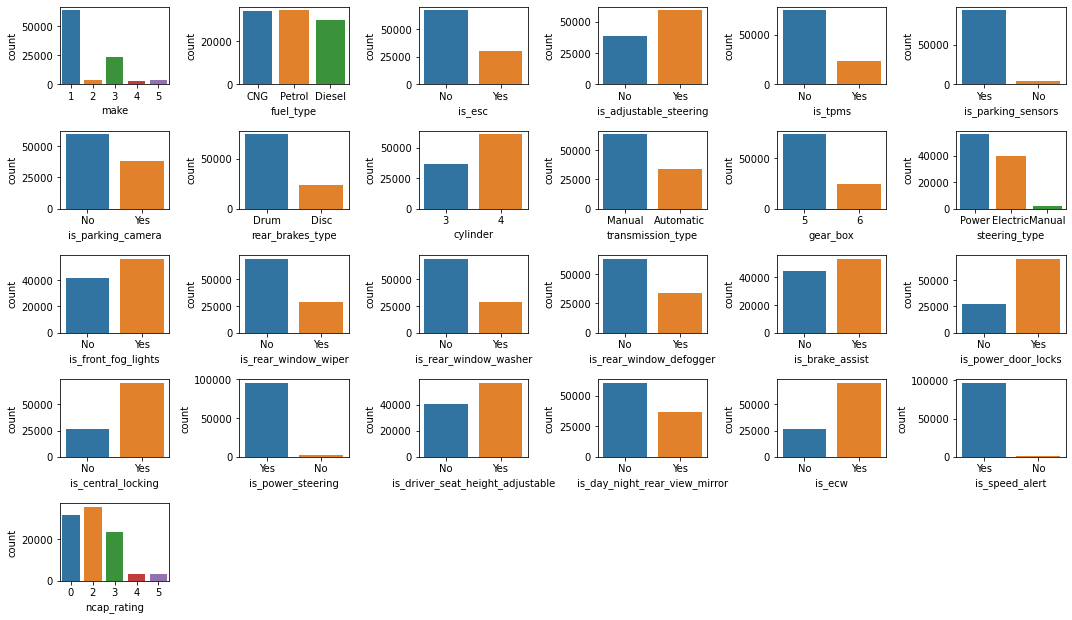

In [60]:
nrows = 6 
ncols = 6
iterator = 1
for i in cat_cols:
    plt.subplot(nrows, ncols, iterator)
    sns.countplot(combined[i])
    iterator +=1
plt.tight_layout()

<AxesSubplot:xlabel='engine_type', ylabel='count'>

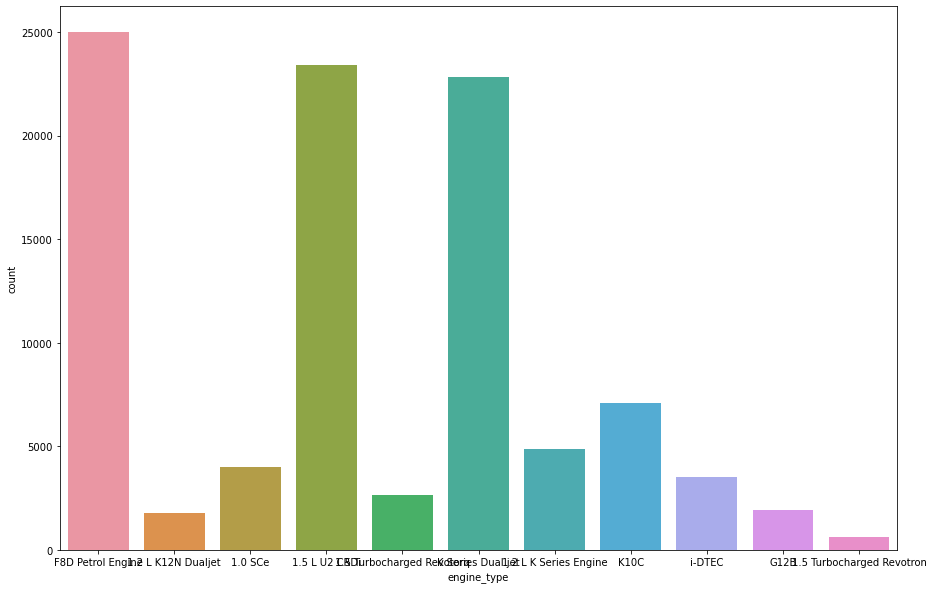

In [61]:
sns.countplot(combined["engine_type"])

<AxesSubplot:xlabel='max_torque', ylabel='count'>

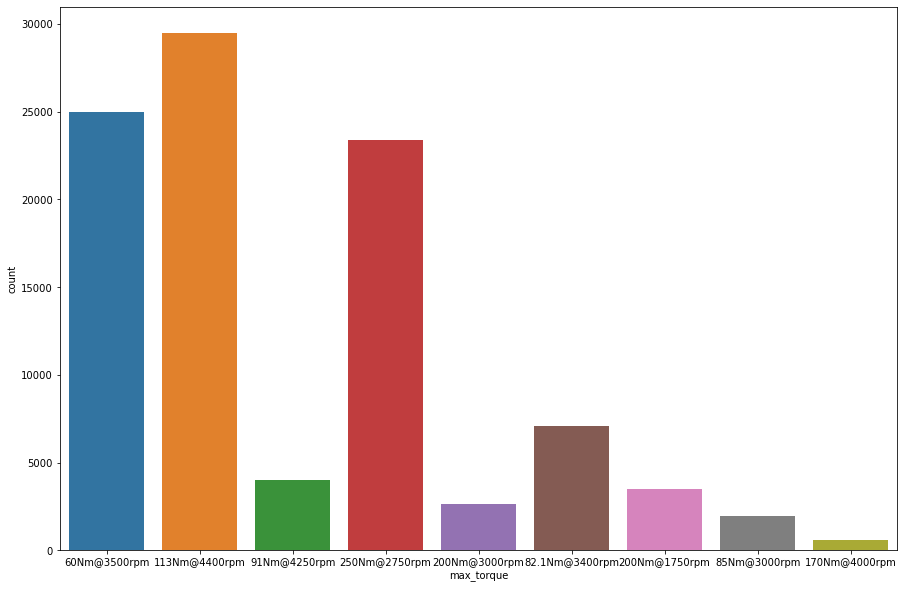

In [62]:
sns.countplot(combined["max_torque"])

<AxesSubplot:xlabel='max_power', ylabel='count'>

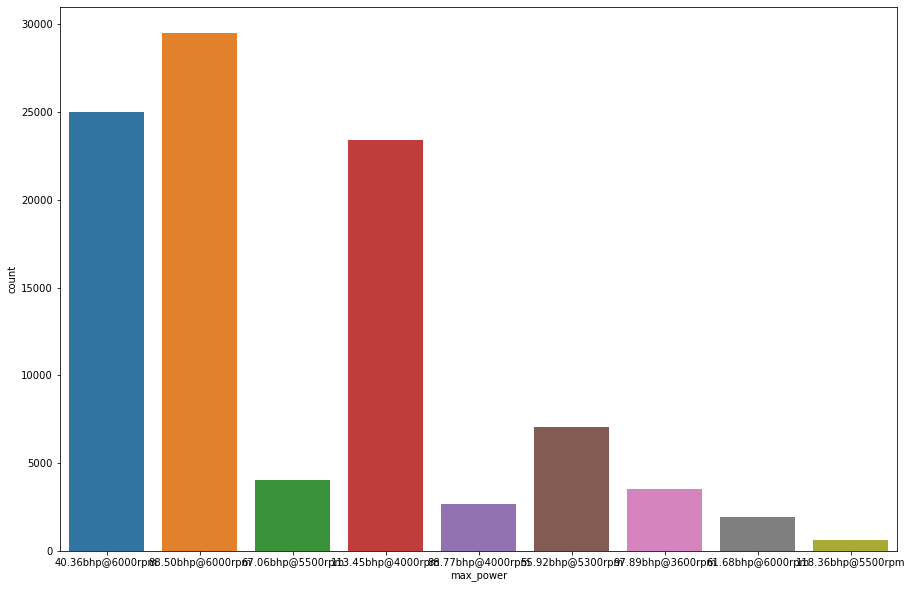

In [63]:
sns.countplot(combined["max_power"])

<AxesSubplot:xlabel='rear_brakes_type'>

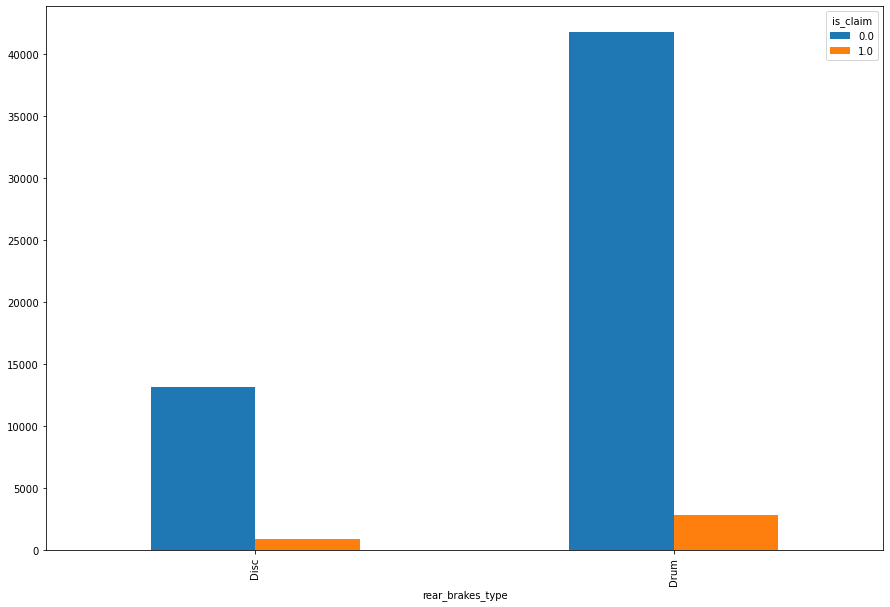

In [67]:
pd.crosstab(combined.rear_brakes_type, combined.is_claim).plot(kind ="bar")

In [69]:
# Bivariate Analysis  Cat - Cat

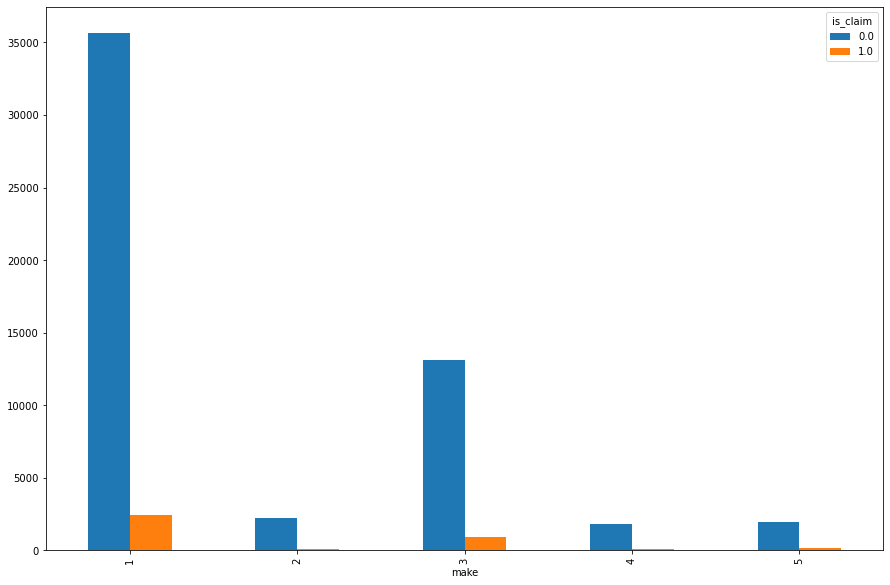

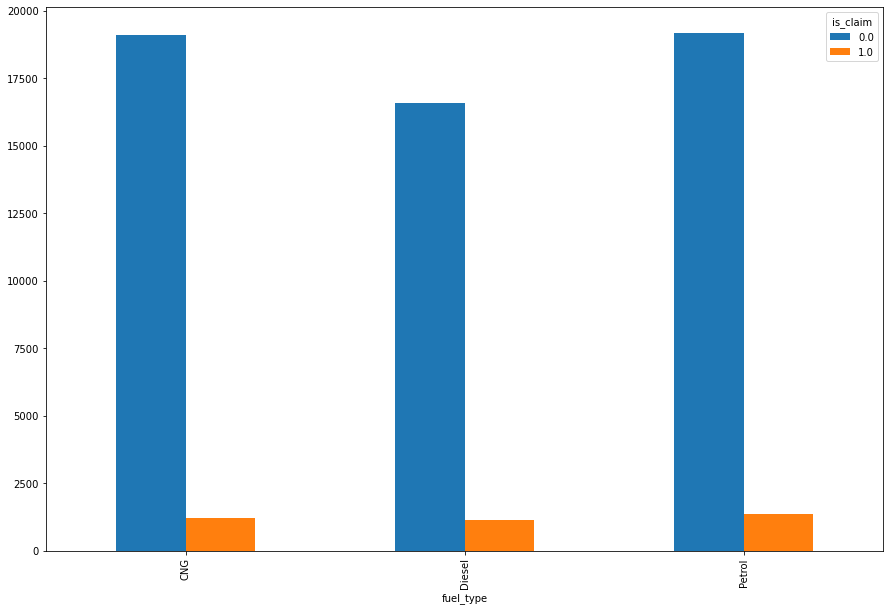

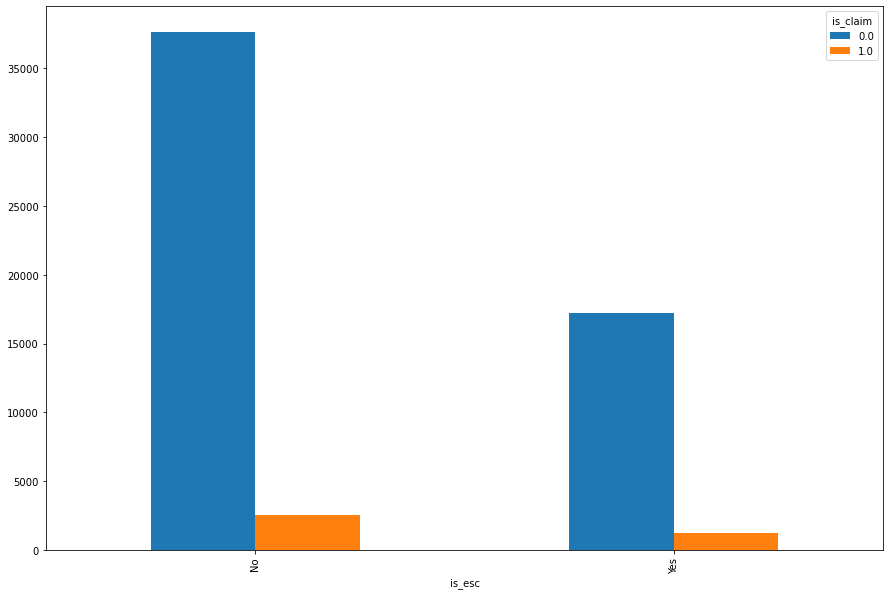

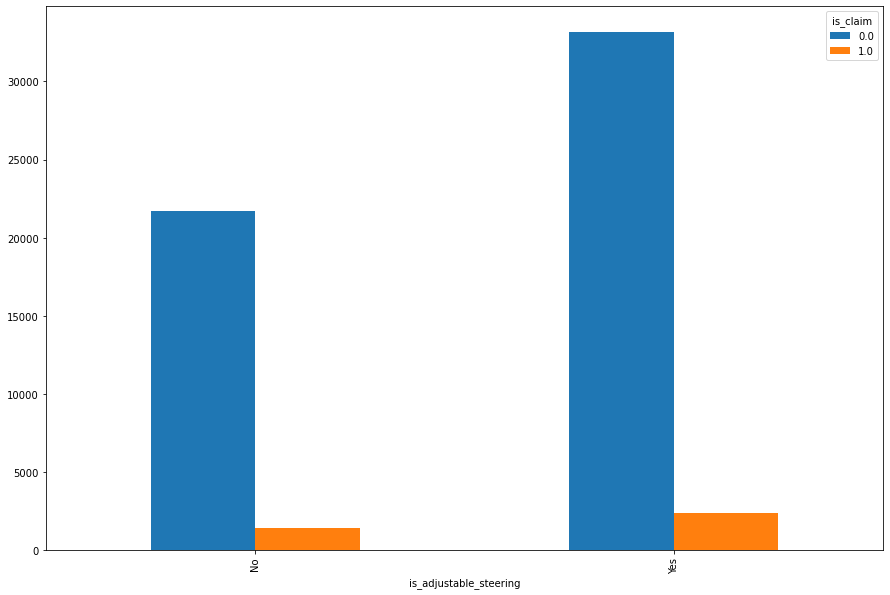

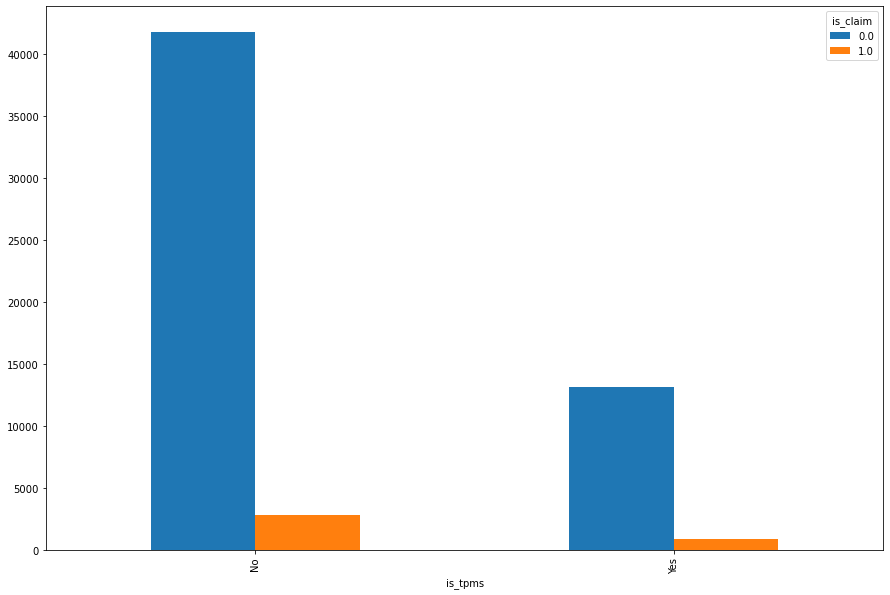

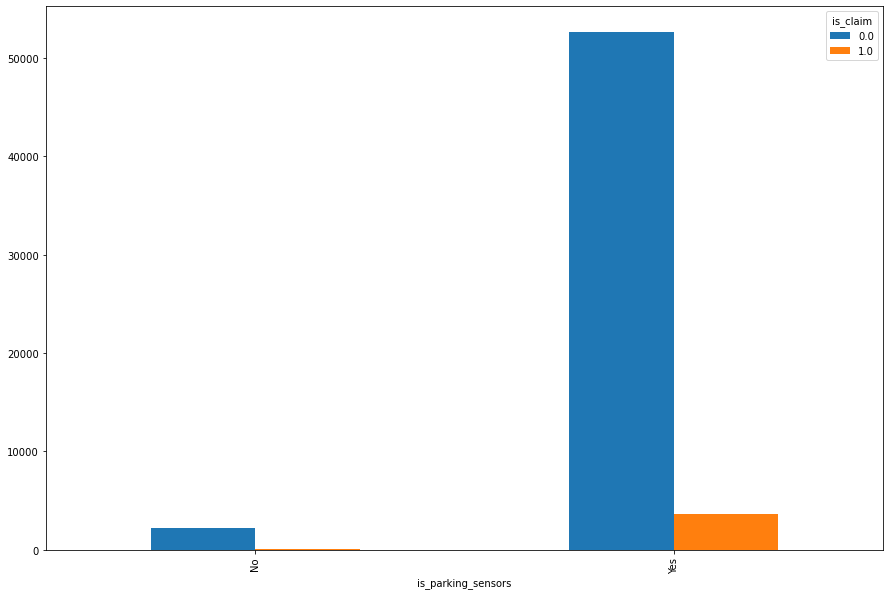

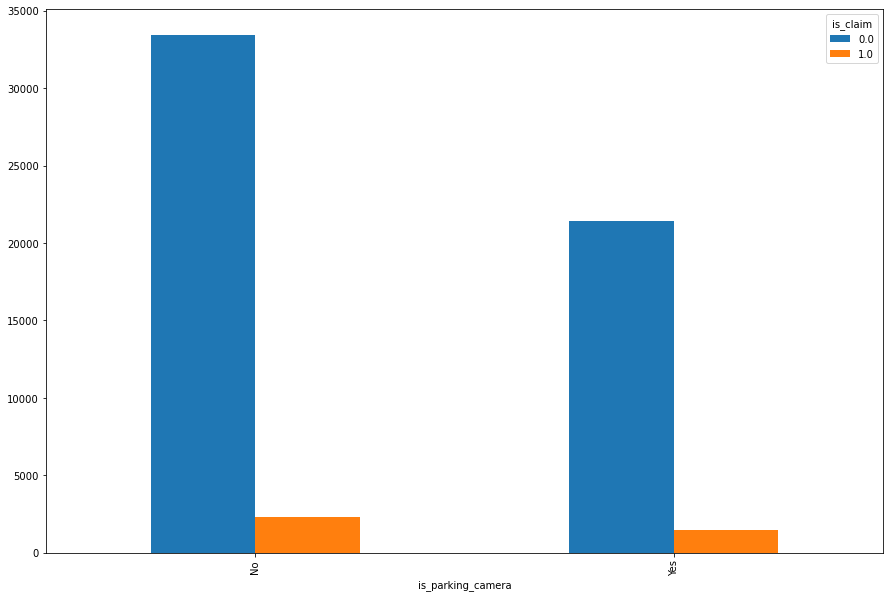

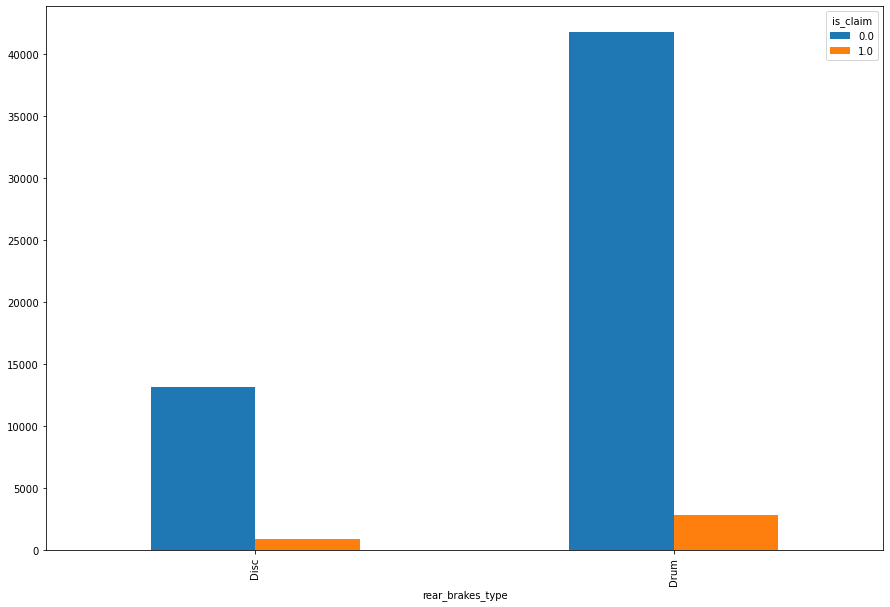

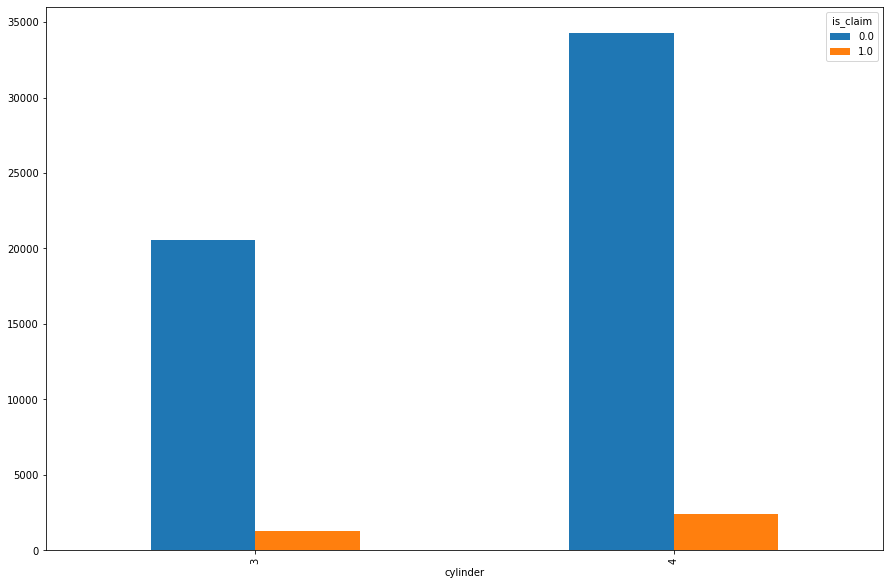

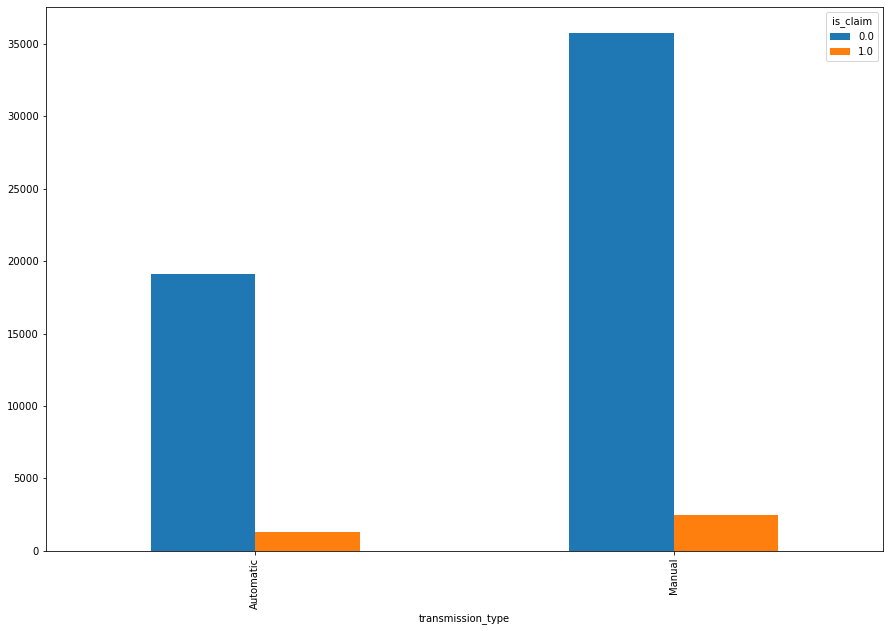

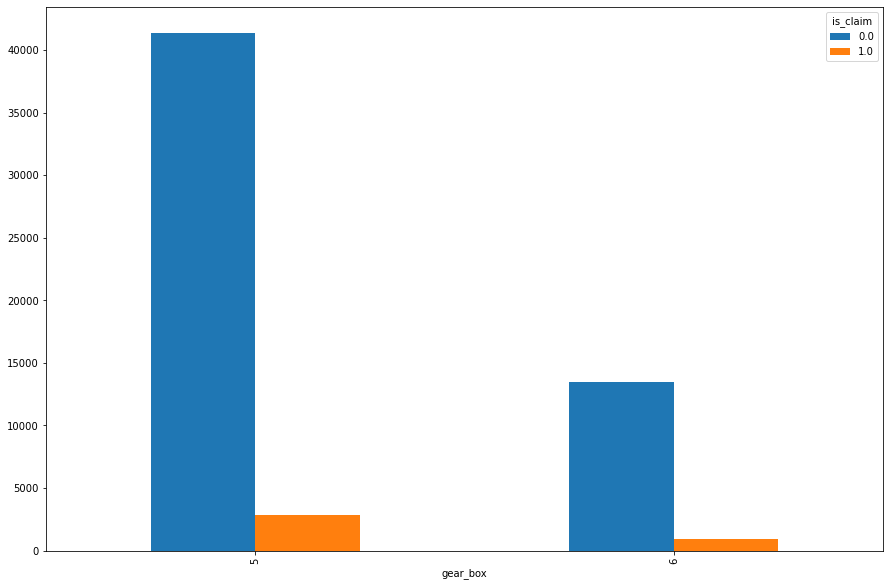

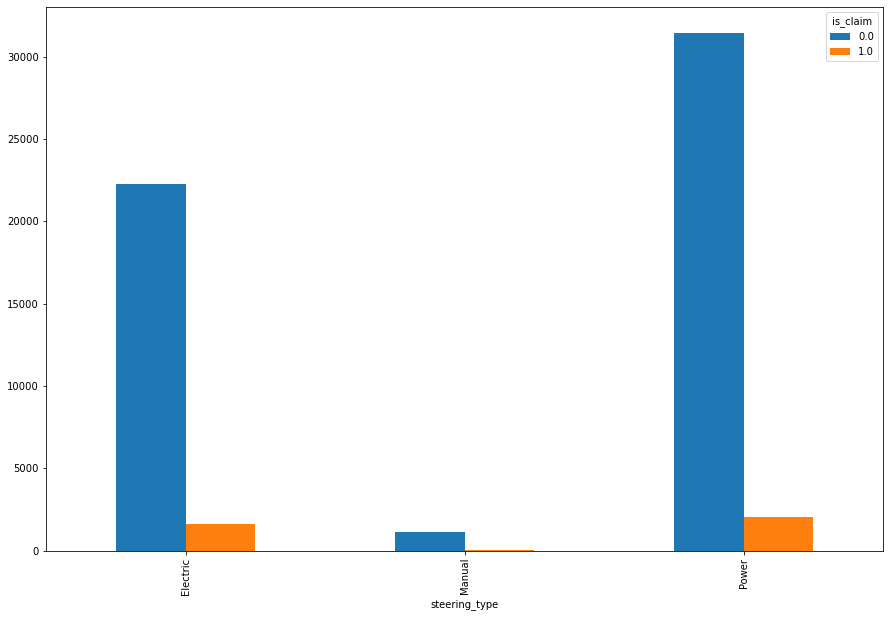

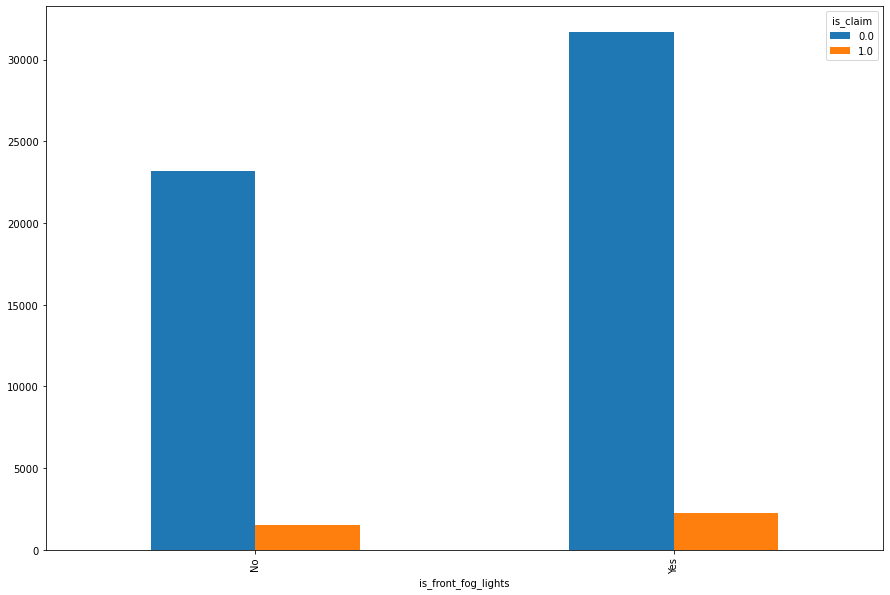

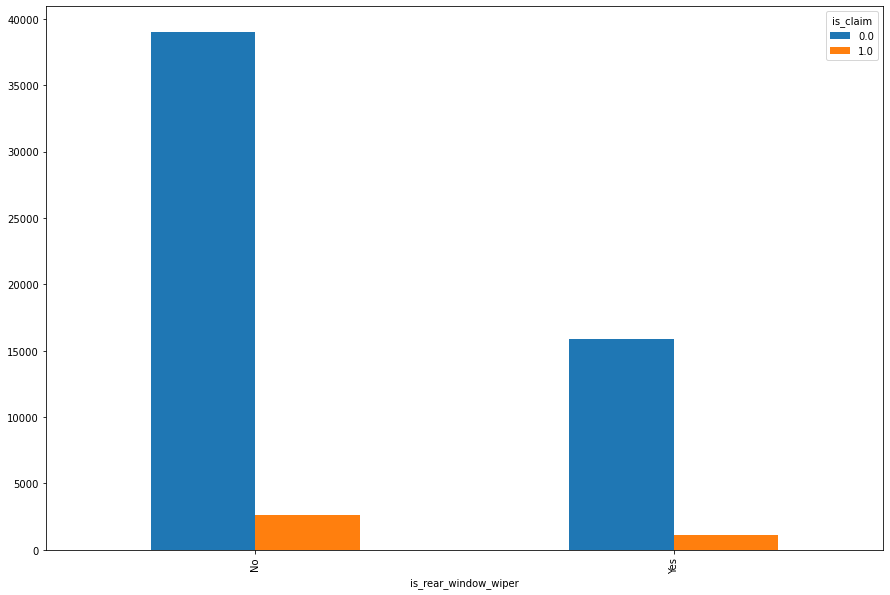

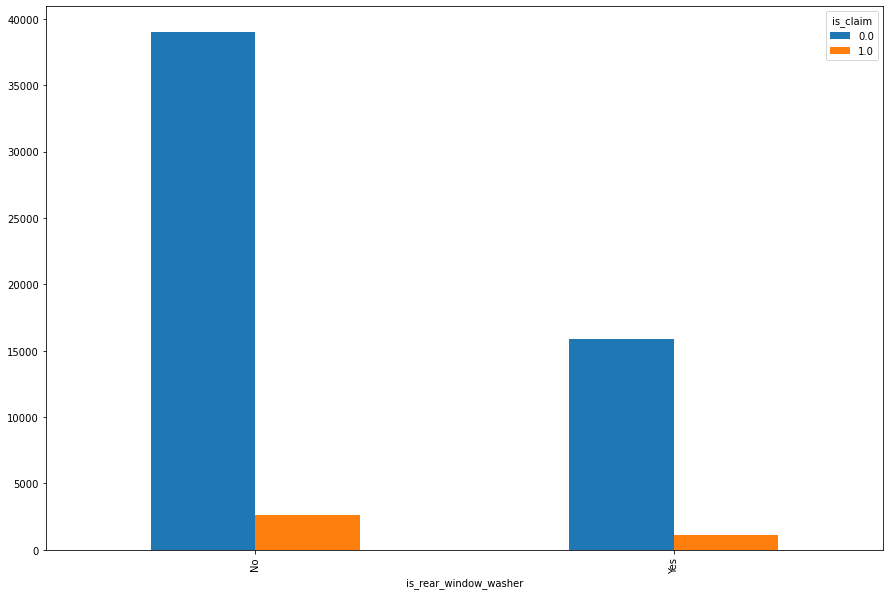

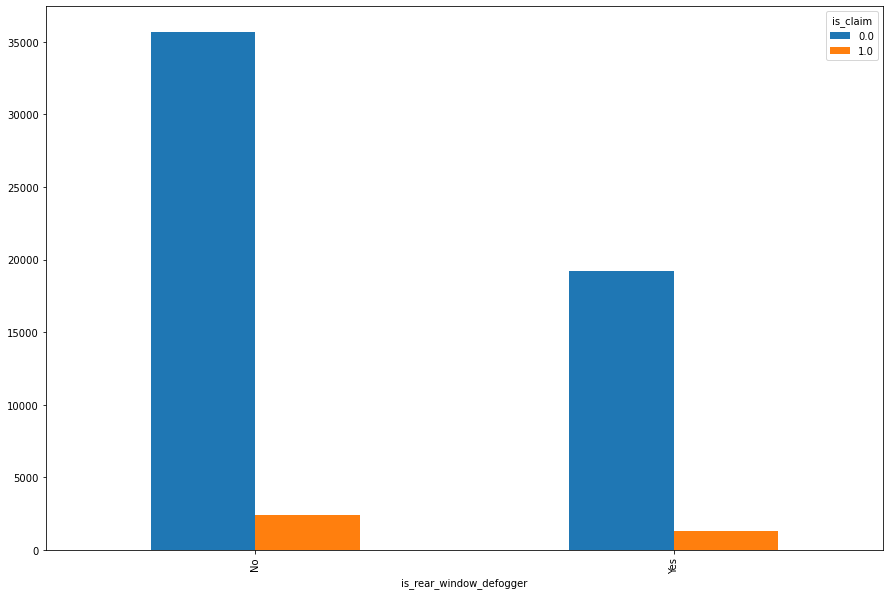

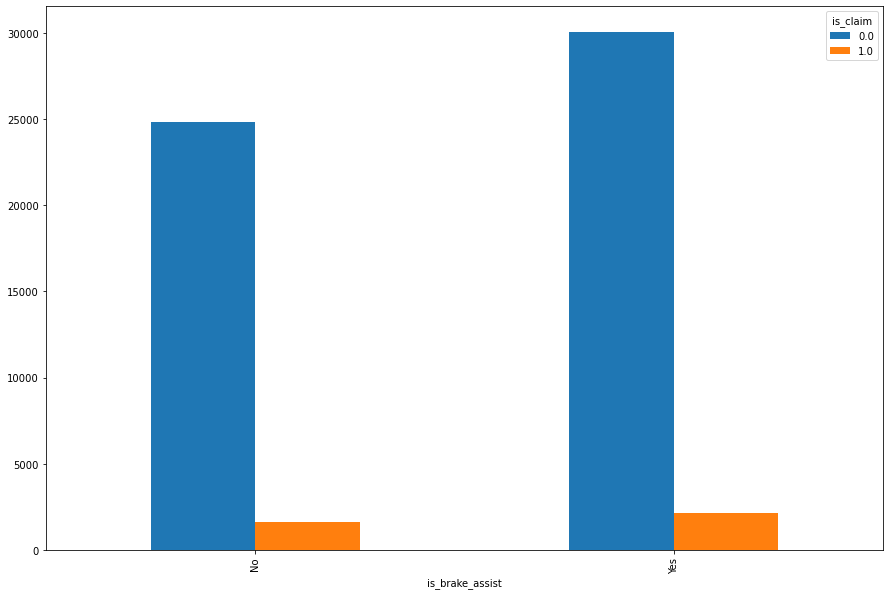

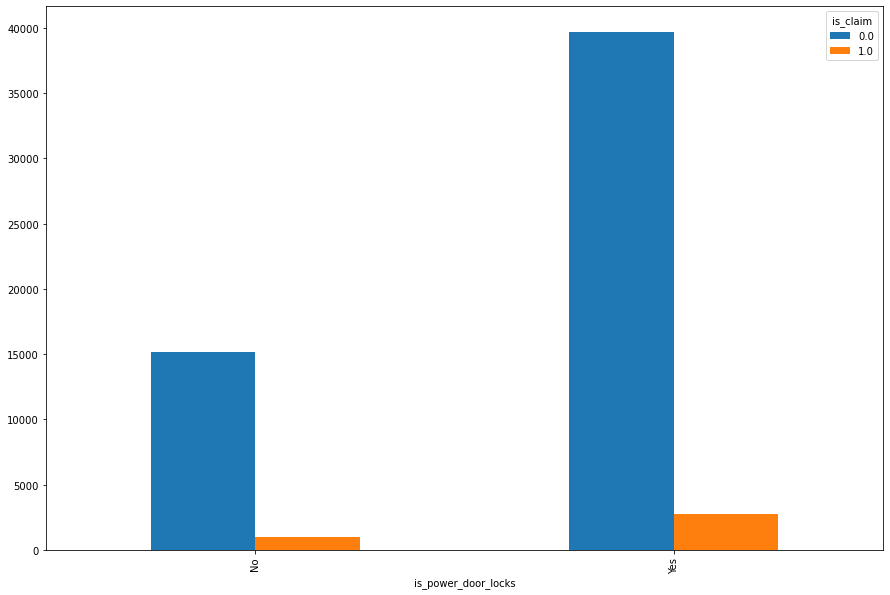

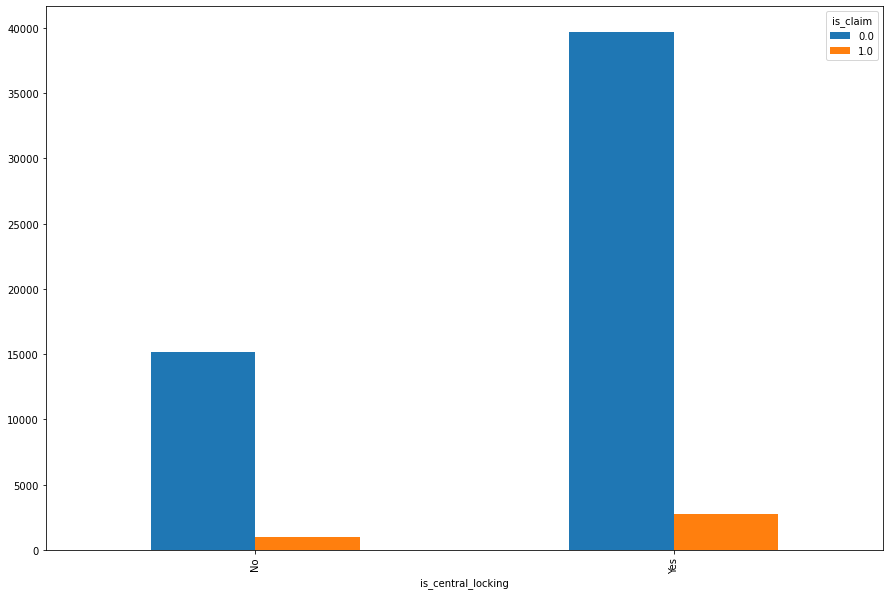

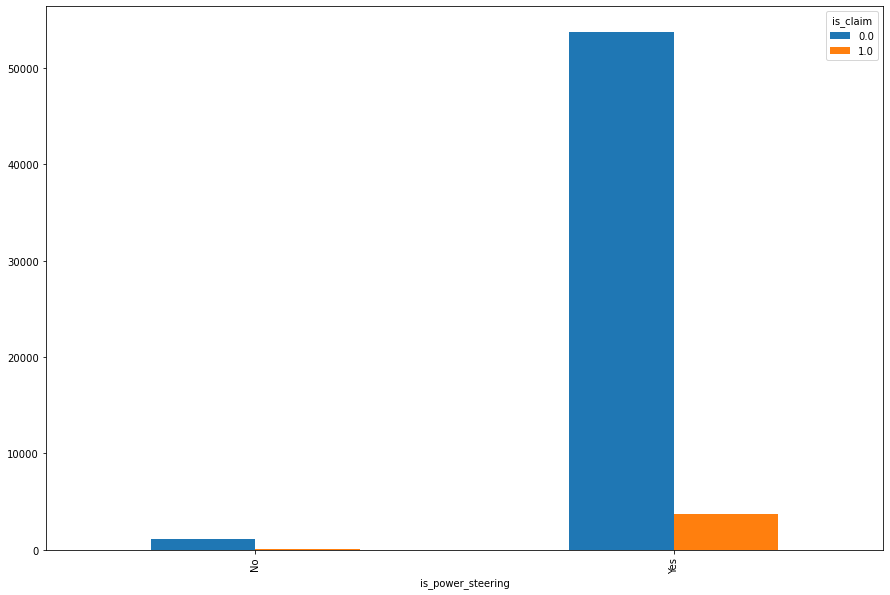

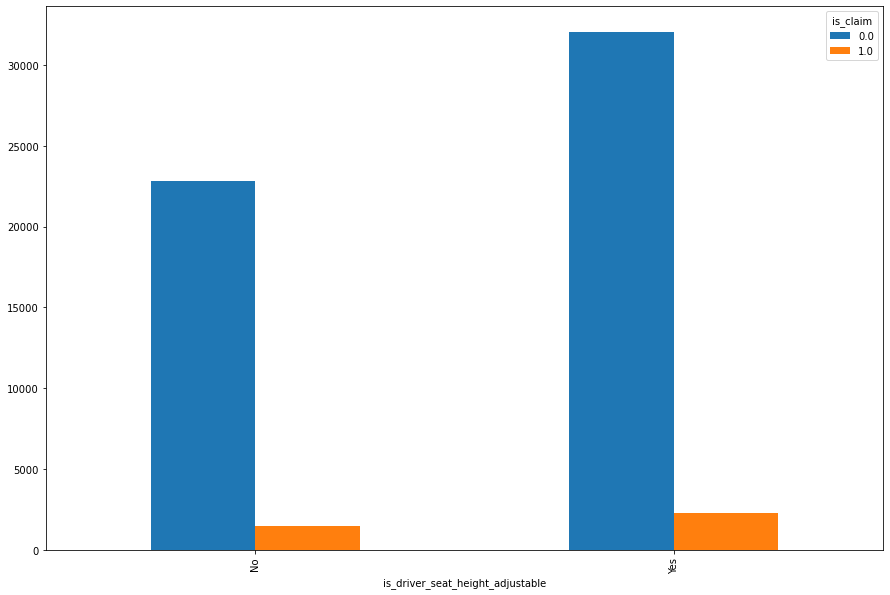

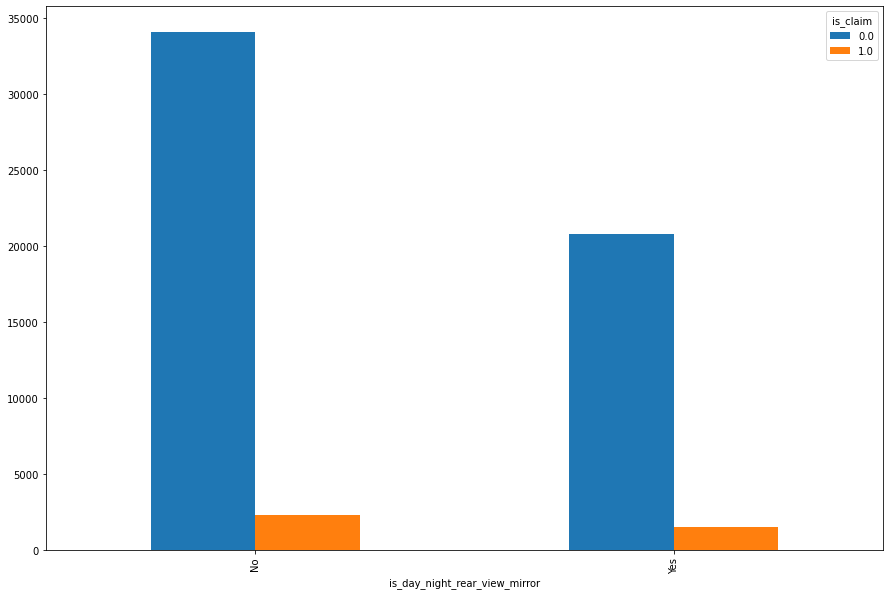

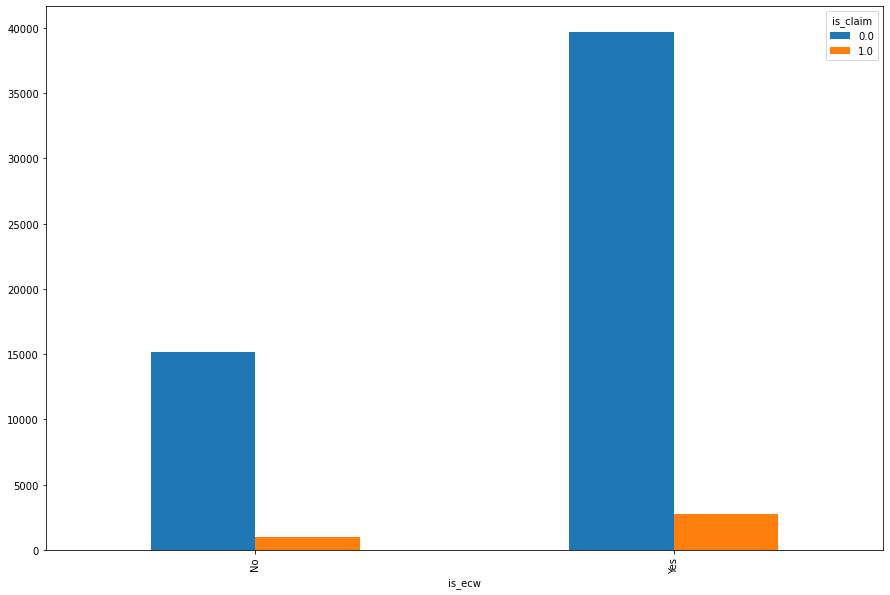

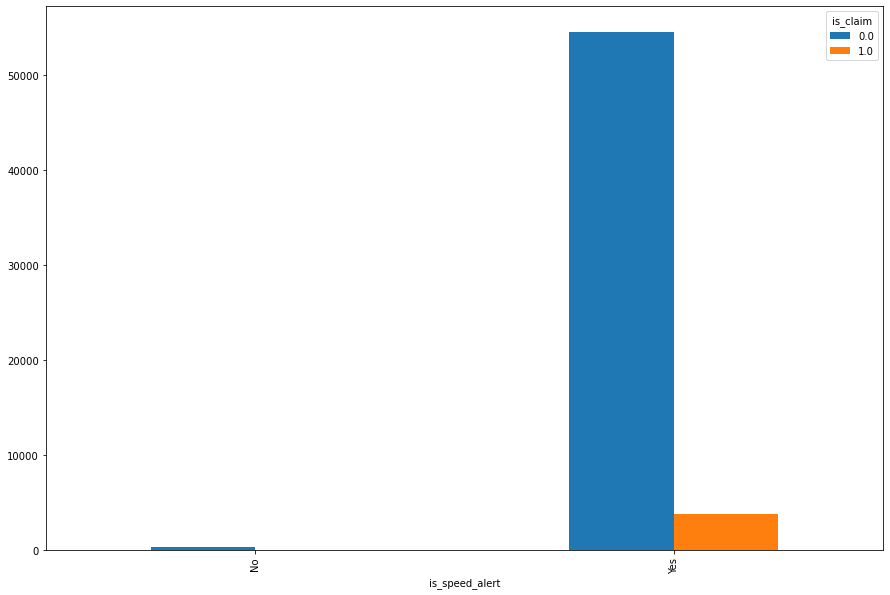

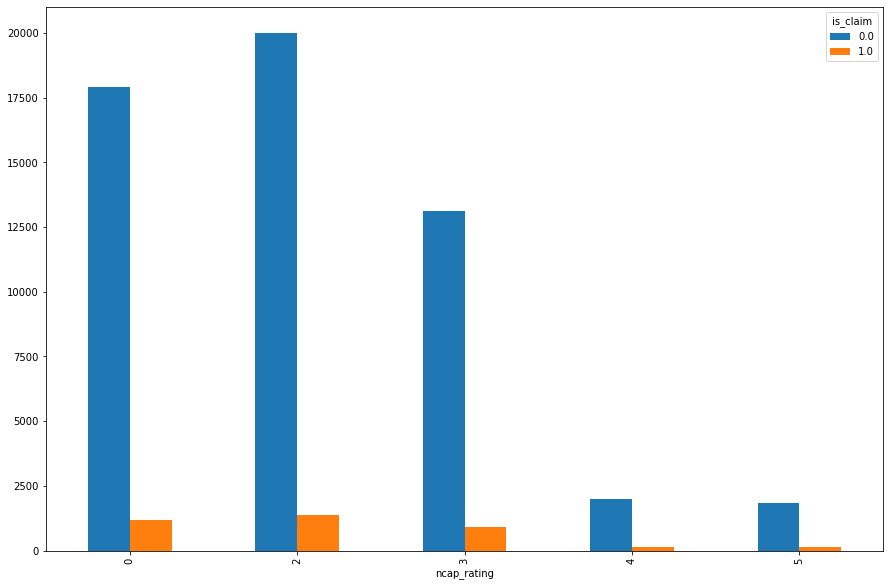

In [70]:
for i in cat_cols:
    pd.crosstab(combined.loc[:,i], combined.is_claim).plot(kind= "bar")
    plt.show()

In [77]:
# Statistical Test
import scipy.stats as stats

In [75]:
category = combined.select_dtypes(object)

In [83]:
signi = []
for i in category:
    tb1= pd.crosstab(train.loc[:,i],train.is_claim)
    test, pvalue, df, exp = stats.chi2_contingency(tb1)
    if pvalue <0.05:
        print(i, "    ", pvalue)
        signi.append(i)

area_cluster      1.412557511595789e-11
segment      0.02738747673628079
model      0.02949022219663932
max_torque      0.012915422090714527
max_power      0.012915422090714527
engine_type      0.029490222196639326
is_adjustable_steering      0.0008041954126638532
is_parking_sensors      0.046026600078480424
cylinder      0.0012196212137077615
is_front_fog_lights      0.004438415801344458
is_brake_assist      0.008799083467312552
is_driver_seat_height_adjustable      0.010185701302166342


In [86]:
signi

['area_cluster',
 'segment',
 'model',
 'max_torque',
 'max_power',
 'engine_type',
 'is_adjustable_steering',
 'is_parking_sensors',
 'cylinder',
 'is_front_fog_lights',
 'is_brake_assist',
 'is_driver_seat_height_adjustable']

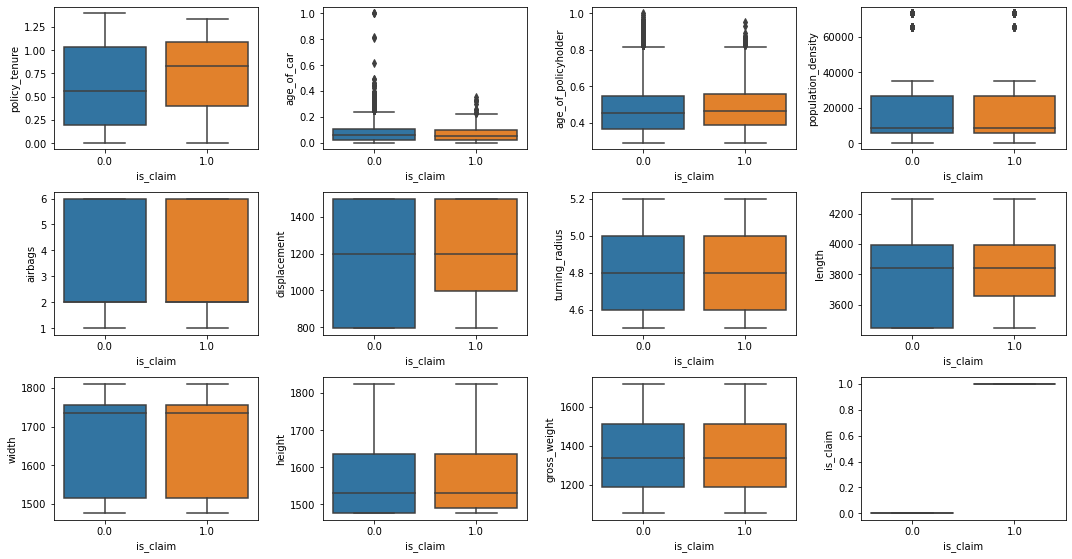

In [95]:
# Numerical Cols

num_cols = combined.select_dtypes(np.number).columns
nrows = 4
ncols = 4
iterator =1
for i in num_cols:
    plt.subplot(nrows, ncols, iterator)
    sns.boxplot(combined.is_claim,combined[i])
    iterator +=1
plt.tight_layout()
plt.show()

In [98]:
# Statistical test on numerical vs target
signinum = []
for i in num_cols:
    zero = train.loc[train.is_claim==0,i]
    one =train.loc[train.is_claim==1,i]
    test, pvalue = stats.ttest_ind(zero, one)
    if pvalue <0.05:
        signinum.append(i)
        print(i)

policy_tenure
age_of_car
age_of_policyholder
population_density
width
is_claim


In [116]:
# Consolidate
finaldata = combined.loc[:,signi + signinum]

In [117]:
finaldata.columns

Index(['area_cluster', 'segment', 'model', 'max_torque', 'max_power',
       'engine_type', 'is_adjustable_steering', 'is_parking_sensors',
       'cylinder', 'is_front_fog_lights', 'is_brake_assist',
       'is_driver_seat_height_adjustable', 'policy_tenure', 'age_of_car',
       'age_of_policyholder', 'population_density', 'width', 'is_claim'],
      dtype='object')

In [118]:
finaldata.head()

,area_cluster,segment,model,max_torque,max_power,engine_type,is_adjustable_steering,is_parking_sensors,cylinder,is_front_fog_lights,is_brake_assist,is_driver_seat_height_adjustable,policy_tenure,age_of_car,age_of_policyholder,population_density,width,is_claim
0,C1,A,M1,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,No,Yes,3,No,No,No,0.515874,0.05,0.644231,4990,1515,0.0
1,C2,A,M1,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,No,Yes,3,No,No,No,0.672619,0.02,0.375000,27003,1515,0.0
2,C3,A,M1,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,No,Yes,3,No,No,No,0.841110,0.02,0.384615,4076,1515,0.0
3,C4,C1,M2,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K12N Dualjet,Yes,Yes,4,Yes,Yes,Yes,0.900277,0.11,0.432692,21622,1735,0.0
4,C5,A,M3,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,No,No,3,No,No,No,0.596403,0.11,0.634615,34738,1579,0.0


In [110]:
def yes(x):
    if x=="Yes":
        return 1
    else:
        return 0

In [119]:
for col in finaldata:
    if col.startswith("is"):
        finaldata[col].replace({"Yes":1,"No":0}, inplace =True)

In [138]:
finaldata.head()

,area_cluster,segment,model,max_torque,max_power,engine_type,is_adjustable_steering,is_parking_sensors,cylinder,is_front_fog_lights,is_brake_assist,is_driver_seat_height_adjustable,policy_tenure,age_of_car,age_of_policyholder,population_density,width,is_claim,Nm,Torque,bhp,power
0,C1,A,M1,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,0,1,3,0,0,0,0.515874,0.05,0.644231,4990,1515,0.0,60.0,3500.0,40.36,6000.0
1,C2,A,M1,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,0,1,3,0,0,0,0.672619,0.02,0.375000,27003,1515,0.0,60.0,3500.0,40.36,6000.0
2,C3,A,M1,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,0,1,3,0,0,0,0.841110,0.02,0.384615,4076,1515,0.0,60.0,3500.0,40.36,6000.0
3,C4,C1,M2,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K12N Dualjet,1,1,4,1,1,1,0.900277,0.11,0.432692,21622,1735,0.0,113.0,4400.0,88.50,6000.0
4,C5,A,M3,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,0,0,3,0,0,0,0.596403,0.11,0.634615,34738,1579,0.0,91.0,4250.0,67.06,5500.0


In [122]:
# max_torque and max_power

In [123]:
finaldata[["Nm","Torque"]] = finaldata.max_torque.str.split("@", expand = True)

In [126]:
finaldata[["bhp","power"]] = finaldata.max_power.str.split("@", expand = True)

In [131]:
finaldata.Nm =finaldata.Nm.apply(lambda x : float(x[:-2]))

In [132]:
finaldata.Torque =finaldata.Torque.apply(lambda x : float(x[:-3]))

In [134]:
finaldata.bhp =finaldata.bhp.apply(lambda x : float(x[:-3]))

In [135]:
finaldata.power =finaldata.power.apply(lambda x : float(x[:-3]))

<AxesSubplot:xlabel='policy_tenure', ylabel='age_of_car'>

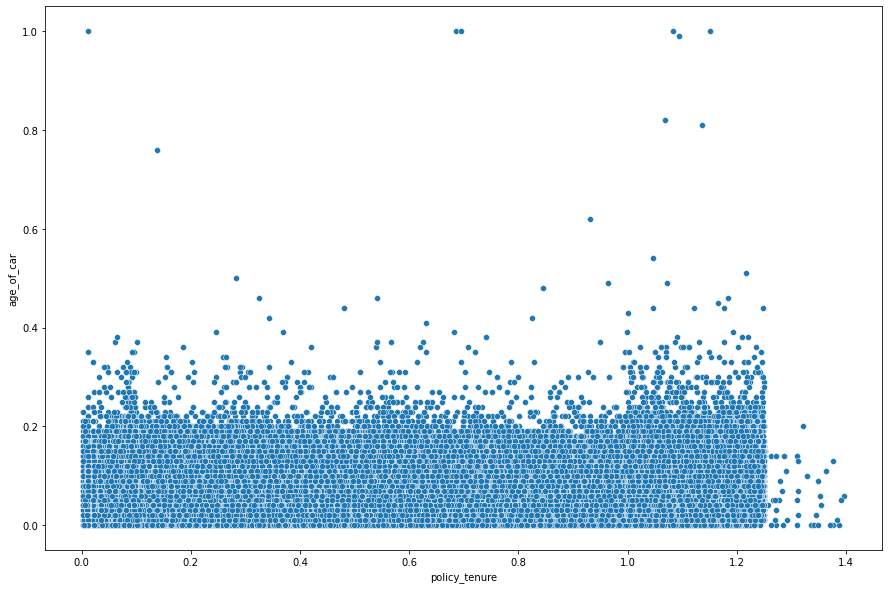

In [137]:
sns.scatterplot(finaldata.policy_tenure, finaldata.age_of_car)

<AxesSubplot:xlabel='age_of_car', ylabel='age_of_policyholder'>

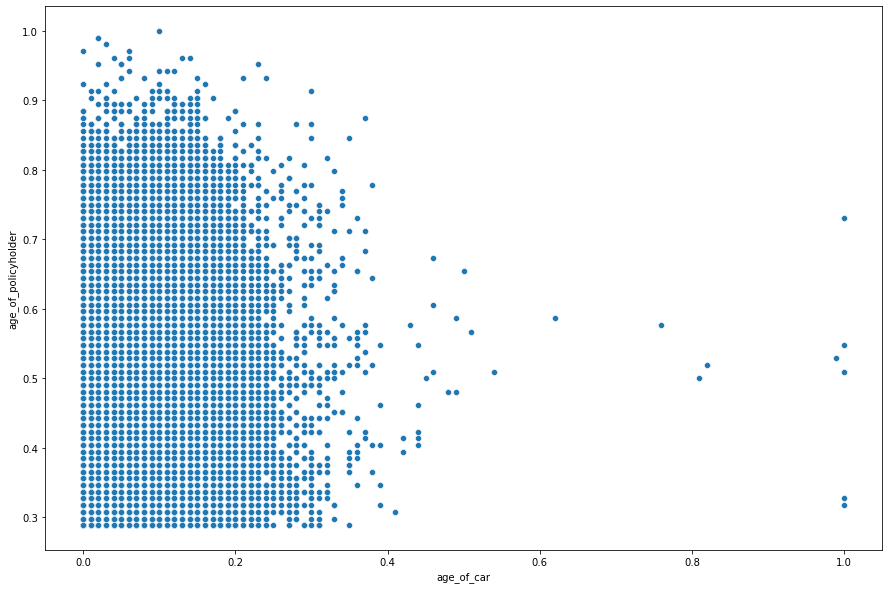

In [139]:
sns.scatterplot(finaldata.age_of_car, finaldata.age_of_policyholder)

In [140]:
finaldata["speed"] = finaldata.Torque/finaldata.Nm

In [150]:
list_engines = finaldata.engine_type.value_counts()[0:3].index
list_engines

Index(['F8D Petrol Engine', '1.5 L U2 CRDi', 'K Series Dual jet'], dtype='object')

In [148]:

zero = finaldata.loc[finaldata.is_claim==0,"speed"]
one = finaldata.loc[finaldata.is_claim==1,"speed"]
test, pvalue = stats.ttest_ind(zero, one)
pvalue


0.25289360461216204

In [151]:
def engine_types(x):
    if x in list_engines:
        return "Top3"
    else:
        return "Others"

In [152]:
finaldata["engine_types"] = finaldata.engine_type.apply(engine_types)

In [155]:
finaldata.drop(["max_torque","max_power","engine_type"],axis= 1, inplace =True)

In [157]:
# splitting the data in train and test

In [158]:
newtrain = finaldata.loc[0:train.shape[0]-1,:]
newtest = finaldata.loc[train.shape[0]:,:]

In [161]:
newtest.drop("is_claim", axis =1, inplace =True)

In [162]:
newtest.shape

(39063, 20)

In [163]:
pip install category_encoders

In [165]:
import category_encoders as ce 
finaldata.columns


Index(['area_cluster', 'segment', 'model', 'is_adjustable_steering',
       'is_parking_sensors', 'cylinder', 'is_front_fog_lights',
       'is_brake_assist', 'is_driver_seat_height_adjustable', 'policy_tenure',
       'age_of_car', 'age_of_policyholder', 'population_density', 'width',
       'is_claim', 'Nm', 'Torque', 'bhp', 'power', 'speed', 'engine_types'],
      dtype='object')

In [166]:
target_encoding = ce.TargetEncoder(cols=['area_cluster', 'segment', 'model'])

In [169]:
x = newtrain.drop("is_claim",axis =1)
y =newtrain.is_claim
newx = target_encoding.fit_transform(x,y)

In [171]:
newtest  = target_encoding.transform(newtest)

In [172]:
newtest = pd.get_dummies(newtest, drop_first=True)

In [173]:
newx = pd.get_dummies(newx, drop_first=True)

In [174]:
newx.head()

,area_cluster,segment,model,is_adjustable_steering,is_parking_sensors,is_front_fog_lights,is_brake_assist,is_driver_seat_height_adjustable,policy_tenure,age_of_car,age_of_policyholder,population_density,width,Nm,Torque,bhp,power,speed,cylinder_4,engine_types_Top3
0,0.051771,0.060389,0.061413,0,1,0,0,0,0.515874,0.05,0.644231,4990,1515,60.0,3500.0,40.36,6000.0,58.333333,0,1
1,0.070825,0.060389,0.061413,0,1,0,0,0,0.672619,0.02,0.375000,27003,1515,60.0,3500.0,40.36,6000.0,58.333333,0,1
2,0.070972,0.060389,0.061413,0,1,0,0,0,0.841110,0.02,0.384615,4076,1515,60.0,3500.0,40.36,6000.0,58.333333,0,1
3,0.076692,0.064099,0.074074,1,1,1,1,1,0.900277,0.11,0.432692,21622,1735,113.0,4400.0,88.50,6000.0,38.938053,1,0
4,0.057745,0.060389,0.053940,0,0,0,0,0,0.596403,0.11,0.634615,34738,1579,91.0,4250.0,67.06,5500.0,46.703297,0,0


In [179]:
# Standard Scalar
from sklearn.preprocessing import StandardScaler
sc =StandardScaler()

listcols = [ 'population_density', 'width', 'Nm', 'Torque',
       'bhp', 'power', 'speed']
for i in listcols:
    newx.loc[:,i] = sc.fit_transform(pd.DataFrame(newx.loc[:,i]))
    newtest.loc[:,i] = sc.transform(pd.DataFrame(newtest.loc[:,i]))

In [208]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Initiate Machines
logreg = LogisticRegression()
dtree = DecisionTreeClassifier()
rf = RandomForestClassifier()
gbm = GradientBoostingClassifier()
xgb = XGBClassifier()

# Initiate the KFold
kfold = StratifiedKFold(n_splits=5 , shuffle=True, random_state=0)

In [209]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
newx, y = sm.fit_resample(newx,y)

In [210]:
# Kfold cross validation
pred = []
for train_index, test_index in kfold.split(newx, y):
    xtrain =newx.loc[train_index]
    ytrain = y.loc[train_index]
    pred.append(logreg.fit(xtrain, ytrain).predict(newtest))

In [213]:
# Kfold cross validation
pred = []
for train_index, test_index in kfold.split(newx, y):
    xtrain =newx.loc[train_index]
    ytrain = y.loc[train_index]
    pred.append(dtree.fit(xtrain, ytrain).predict(newtest))

In [216]:
# Kfold cross validation
pred = []
for train_index, test_index in kfold.split(newx, y):
    xtrain =newx.loc[train_index]
    ytrain = y.loc[train_index]
    pred.append(rf.fit(xtrain, ytrain).predict(newtest))

In [219]:
# Kfold cross validation
pred = []
for train_index, test_index in kfold.split(newx, y):
    xtrain =newx.loc[train_index]
    ytrain = y.loc[train_index]
    pred.append(gbm.fit(xtrain, ytrain).predict(newtest))

In [223]:
# Submission File

In [ ]:
# Kfold cross validation
pred = []
for train_index, test_index in kfold.split(newx, y):
    xtrain =newx.loc[train_index]
    ytrain = y.loc[train_index]
    pred.append(gbm.fit(xtrain, ytrain).predict(newtest))

In [220]:
finalpred = pd.DataFrame(pred).T.mode(axis =1)

In [221]:
submission = pd.DataFrame({"policy_id":test.policy_id,"is_claim":0})
submission["is_claim"] = finalpred
submission.to_csv("GBM.csv",index =False)

In [236]:
# pip install catboost
#from catboost import Pool, to_classifier, CatBoost
!pip install catboost

In [240]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
cboost =CatBoostClassifier()
params = [{"learning_rate":[0.01,0.001,0.1],"depth":[2,4,6,8]}]

In [242]:
grid = GridSearchCV(estimator=cboost,param_grid=params, cv=5)

In [ ]:
grid.fit(newx,y)

In [ ]:
grid.best_params_

In [247]:
basemodels = [("logreg",logreg),("gbm",gbm),("xgboost",xgb)]
from sklearn.ensemble import StackingClassifier
stack = StackingClassifier(estimators=basemodels, final_estimator = cboost, cv =5)


In [ ]:
# Kfold cross validation
pred = []
for train_index, test_index in kfold.split(newx, y):
    xtrain =newx.loc[train_index]
    ytrain = y.loc[train_index]
    pred.append(stack.fit(xtrain, ytrain).predict(newtest))

Learning rate set to 0.069615
0:	learn: 0.5678355	total: 37.2ms	remaining: 37.2s
1:	learn: 0.4755881	total: 70.9ms	remaining: 35.4s
2:	learn: 0.3968458	total: 105ms	remaining: 34.9s
3:	learn: 0.3470888	total: 139ms	remaining: 34.6s
4:	learn: 0.3036798	total: 173ms	remaining: 34.4s
5:	learn: 0.2709152	total: 214ms	remaining: 35.4s
6:	learn: 0.2419928	total: 262ms	remaining: 37.1s
7:	learn: 0.2210975	total: 297ms	remaining: 36.9s
8:	learn: 0.2087754	total: 336ms	remaining: 37s
9:	learn: 0.1950074	total: 373ms	remaining: 36.9s
10:	learn: 0.1845934	total: 406ms	remaining: 36.5s
11:	learn: 0.1748187	total: 447ms	remaining: 36.8s
12:	learn: 0.1666948	total: 481ms	remaining: 36.5s
13:	learn: 0.1624070	total: 516ms	remaining: 36.3s
14:	learn: 0.1584871	total: 553ms	remaining: 36.3s
15:	learn: 0.1541336	total: 583ms	remaining: 35.9s
16:	learn: 0.1506240	total: 626ms	remaining: 36.2s
17:	learn: 0.1485261	total: 661ms	remaining: 36.1s
18:	learn: 0.1463036	total: 696ms	remaining: 35.9s
19:	learn: 

162:	learn: 0.1237687	total: 5.35s	remaining: 27.5s
163:	learn: 0.1237294	total: 5.39s	remaining: 27.5s
164:	learn: 0.1237058	total: 5.43s	remaining: 27.5s
165:	learn: 0.1236825	total: 5.47s	remaining: 27.5s
166:	learn: 0.1236326	total: 5.52s	remaining: 27.5s
167:	learn: 0.1236078	total: 5.56s	remaining: 27.5s
168:	learn: 0.1235910	total: 5.61s	remaining: 27.6s
169:	learn: 0.1235675	total: 5.64s	remaining: 27.6s
170:	learn: 0.1235458	total: 5.67s	remaining: 27.5s
171:	learn: 0.1235197	total: 5.7s	remaining: 27.5s
172:	learn: 0.1235004	total: 5.73s	remaining: 27.4s
173:	learn: 0.1234564	total: 5.76s	remaining: 27.3s
174:	learn: 0.1234203	total: 5.8s	remaining: 27.3s
175:	learn: 0.1233886	total: 5.83s	remaining: 27.3s
176:	learn: 0.1233623	total: 5.86s	remaining: 27.2s
177:	learn: 0.1233342	total: 5.88s	remaining: 27.2s
178:	learn: 0.1232937	total: 5.92s	remaining: 27.1s
179:	learn: 0.1232758	total: 5.95s	remaining: 27.1s
180:	learn: 0.1232479	total: 5.98s	remaining: 27.1s
181:	learn: 0.

321:	learn: 0.1200802	total: 12.4s	remaining: 26.2s
322:	learn: 0.1200678	total: 12.5s	remaining: 26.2s
323:	learn: 0.1200343	total: 12.5s	remaining: 26.2s
324:	learn: 0.1200177	total: 12.6s	remaining: 26.1s
325:	learn: 0.1199997	total: 12.6s	remaining: 26.1s
326:	learn: 0.1199935	total: 12.7s	remaining: 26.1s
327:	learn: 0.1199783	total: 12.7s	remaining: 26.1s
328:	learn: 0.1199540	total: 12.8s	remaining: 26s
329:	learn: 0.1199322	total: 12.8s	remaining: 26s
330:	learn: 0.1199119	total: 12.8s	remaining: 25.9s
331:	learn: 0.1198980	total: 12.9s	remaining: 25.9s
332:	learn: 0.1198801	total: 12.9s	remaining: 25.9s
333:	learn: 0.1198598	total: 13s	remaining: 25.8s
334:	learn: 0.1198439	total: 13s	remaining: 25.8s
335:	learn: 0.1198266	total: 13s	remaining: 25.7s
336:	learn: 0.1198071	total: 13.1s	remaining: 25.7s
337:	learn: 0.1197763	total: 13.1s	remaining: 25.7s
338:	learn: 0.1197596	total: 13.2s	remaining: 25.8s
339:	learn: 0.1197483	total: 13.3s	remaining: 25.8s
340:	learn: 0.1197251	

480:	learn: 0.1170656	total: 19.1s	remaining: 20.6s
481:	learn: 0.1170516	total: 19.1s	remaining: 20.5s
482:	learn: 0.1170372	total: 19.1s	remaining: 20.5s
483:	learn: 0.1170109	total: 19.2s	remaining: 20.4s
484:	learn: 0.1169977	total: 19.2s	remaining: 20.4s
485:	learn: 0.1169800	total: 19.2s	remaining: 20.3s
486:	learn: 0.1169473	total: 19.3s	remaining: 20.3s
487:	learn: 0.1169301	total: 19.3s	remaining: 20.3s
488:	learn: 0.1169179	total: 19.3s	remaining: 20.2s
489:	learn: 0.1168787	total: 19.4s	remaining: 20.2s
490:	learn: 0.1168471	total: 19.4s	remaining: 20.1s
491:	learn: 0.1168314	total: 19.4s	remaining: 20.1s
492:	learn: 0.1168233	total: 19.5s	remaining: 20s
493:	learn: 0.1168163	total: 19.5s	remaining: 20s
494:	learn: 0.1167919	total: 19.5s	remaining: 19.9s
495:	learn: 0.1167649	total: 19.6s	remaining: 19.9s
496:	learn: 0.1167596	total: 19.6s	remaining: 19.8s
497:	learn: 0.1167502	total: 19.6s	remaining: 19.8s
498:	learn: 0.1167299	total: 19.6s	remaining: 19.7s
499:	learn: 0.11

641:	learn: 0.1143560	total: 24.1s	remaining: 13.4s
642:	learn: 0.1143437	total: 24.1s	remaining: 13.4s
643:	learn: 0.1143281	total: 24.1s	remaining: 13.3s
644:	learn: 0.1143182	total: 24.2s	remaining: 13.3s
645:	learn: 0.1143132	total: 24.2s	remaining: 13.3s
646:	learn: 0.1142935	total: 24.2s	remaining: 13.2s
647:	learn: 0.1142663	total: 24.3s	remaining: 13.2s
648:	learn: 0.1142461	total: 24.3s	remaining: 13.1s
649:	learn: 0.1142295	total: 24.3s	remaining: 13.1s
650:	learn: 0.1142203	total: 24.4s	remaining: 13.1s
651:	learn: 0.1142018	total: 24.4s	remaining: 13s
652:	learn: 0.1141854	total: 24.4s	remaining: 13s
653:	learn: 0.1141663	total: 24.4s	remaining: 12.9s
654:	learn: 0.1141539	total: 24.5s	remaining: 12.9s
655:	learn: 0.1141333	total: 24.5s	remaining: 12.9s
656:	learn: 0.1141145	total: 24.5s	remaining: 12.8s
657:	learn: 0.1140991	total: 24.6s	remaining: 12.8s
658:	learn: 0.1140846	total: 24.6s	remaining: 12.7s
659:	learn: 0.1140644	total: 24.6s	remaining: 12.7s
660:	learn: 0.11

...

53:	learn: 0.1258735	total: 1.54s	remaining: 27s
54:	learn: 0.1257812	total: 1.57s	remaining: 27s
55:	learn: 0.1256778	total: 1.6s	remaining: 27s
56:	learn: 0.1255906	total: 1.62s	remaining: 26.8s
57:	learn: 0.1255305	total: 1.65s	remaining: 26.8s
58:	learn: 0.1254460	total: 1.68s	remaining: 26.7s
59:	learn: 0.1254093	total: 1.7s	remaining: 26.6s
60:	learn: 0.1253682	total: 1.73s	remaining: 26.6s
61:	learn: 0.1252899	total: 1.76s	remaining: 26.7s
62:	learn: 0.1252251	total: 1.79s	remaining: 26.7s
63:	learn: 0.1251600	total: 1.82s	remaining: 26.7s
64:	learn: 0.1250977	total: 1.85s	remaining: 26.6s
65:	learn: 0.1250154	total: 1.88s	remaining: 26.6s
66:	learn: 0.1249510	total: 1.9s	remaining: 26.5s
67:	learn: 0.1248956	total: 1.93s	remaining: 26.5s
68:	learn: 0.1248486	total: 1.96s	remaining: 26.4s
69:	learn: 0.1247860	total: 1.99s	remaining: 26.5s
70:	learn: 0.1247253	total: 2.02s	remaining: 26.5s
71:	learn: 0.1246561	total: 2.04s	remaining: 26.4s
72:	learn: 0.1246085	total: 2.08s	remain

216:	learn: 0.1201472	total: 6.29s	remaining: 22.7s
217:	learn: 0.1201257	total: 6.32s	remaining: 22.7s
218:	learn: 0.1201090	total: 6.34s	remaining: 22.6s
219:	learn: 0.1200856	total: 6.37s	remaining: 22.6s
220:	learn: 0.1200650	total: 6.4s	remaining: 22.6s
221:	learn: 0.1200337	total: 6.43s	remaining: 22.5s
222:	learn: 0.1200067	total: 6.46s	remaining: 22.5s
223:	learn: 0.1199874	total: 6.48s	remaining: 22.5s
224:	learn: 0.1199674	total: 6.52s	remaining: 22.4s
225:	learn: 0.1199370	total: 6.54s	remaining: 22.4s
226:	learn: 0.1199133	total: 6.57s	remaining: 22.4s
227:	learn: 0.1198936	total: 6.6s	remaining: 22.4s
228:	learn: 0.1198682	total: 6.63s	remaining: 22.3s
229:	learn: 0.1198520	total: 6.66s	remaining: 22.3s
230:	learn: 0.1198221	total: 6.69s	remaining: 22.3s
231:	learn: 0.1197989	total: 6.72s	remaining: 22.2s
232:	learn: 0.1197660	total: 6.76s	remaining: 22.2s
233:	learn: 0.1197406	total: 6.79s	remaining: 22.2s
234:	learn: 0.1197184	total: 6.82s	remaining: 22.2s
235:	learn: 0.

380:	learn: 0.1166646	total: 11.7s	remaining: 19s
381:	learn: 0.1166395	total: 11.7s	remaining: 19s
382:	learn: 0.1166101	total: 11.8s	remaining: 19s
383:	learn: 0.1165883	total: 11.8s	remaining: 18.9s
384:	learn: 0.1165791	total: 11.8s	remaining: 18.9s
385:	learn: 0.1165546	total: 11.9s	remaining: 18.9s
386:	learn: 0.1165349	total: 11.9s	remaining: 18.9s
387:	learn: 0.1165160	total: 12s	remaining: 18.9s
388:	learn: 0.1164982	total: 12s	remaining: 18.8s
389:	learn: 0.1164814	total: 12s	remaining: 18.8s
390:	learn: 0.1164674	total: 12.1s	remaining: 18.8s
391:	learn: 0.1164508	total: 12.1s	remaining: 18.8s
392:	learn: 0.1164368	total: 12.1s	remaining: 18.7s
393:	learn: 0.1164232	total: 12.2s	remaining: 18.7s
394:	learn: 0.1163868	total: 12.2s	remaining: 18.7s
395:	learn: 0.1163761	total: 12.2s	remaining: 18.7s
396:	learn: 0.1163583	total: 12.3s	remaining: 18.7s
397:	learn: 0.1163394	total: 12.3s	remaining: 18.6s
398:	learn: 0.1163279	total: 12.3s	remaining: 18.6s
399:	learn: 0.1163175	to

541:	learn: 0.1140403	total: 18s	remaining: 15.2s
542:	learn: 0.1140229	total: 18s	remaining: 15.2s
543:	learn: 0.1140153	total: 18.1s	remaining: 15.1s
544:	learn: 0.1139993	total: 18.1s	remaining: 15.1s
545:	learn: 0.1139836	total: 18.1s	remaining: 15.1s
546:	learn: 0.1139614	total: 18.1s	remaining: 15s
547:	learn: 0.1139537	total: 18.2s	remaining: 15s
548:	learn: 0.1139418	total: 18.2s	remaining: 15s
549:	learn: 0.1139148	total: 18.2s	remaining: 14.9s
550:	learn: 0.1138967	total: 18.3s	remaining: 14.9s
551:	learn: 0.1138883	total: 18.3s	remaining: 14.9s
552:	learn: 0.1138755	total: 18.3s	remaining: 14.8s
553:	learn: 0.1138657	total: 18.4s	remaining: 14.8s
554:	learn: 0.1138445	total: 18.4s	remaining: 14.8s
555:	learn: 0.1138351	total: 18.4s	remaining: 14.7s
556:	learn: 0.1138193	total: 18.5s	remaining: 14.7s
557:	learn: 0.1137954	total: 18.5s	remaining: 14.6s
558:	learn: 0.1137857	total: 18.5s	remaining: 14.6s
559:	learn: 0.1137857	total: 18.5s	remaining: 14.6s
560:	learn: 0.1137701	

700:	learn: 0.1116047	total: 23.1s	remaining: 9.86s
701:	learn: 0.1115950	total: 23.1s	remaining: 9.82s
702:	learn: 0.1115856	total: 23.2s	remaining: 9.79s
703:	learn: 0.1115747	total: 23.2s	remaining: 9.75s
704:	learn: 0.1115496	total: 23.2s	remaining: 9.71s
705:	learn: 0.1115397	total: 23.2s	remaining: 9.68s
706:	learn: 0.1115317	total: 23.3s	remaining: 9.64s
707:	learn: 0.1115206	total: 23.3s	remaining: 9.61s
708:	learn: 0.1115019	total: 23.3s	remaining: 9.57s
709:	learn: 0.1114898	total: 23.4s	remaining: 9.54s
710:	learn: 0.1114852	total: 23.4s	remaining: 9.51s
711:	learn: 0.1114740	total: 23.4s	remaining: 9.47s
712:	learn: 0.1114590	total: 23.4s	remaining: 9.44s
713:	learn: 0.1114522	total: 23.5s	remaining: 9.4s
714:	learn: 0.1114343	total: 23.5s	remaining: 9.37s
715:	learn: 0.1114124	total: 23.5s	remaining: 9.34s
716:	learn: 0.1113863	total: 23.6s	remaining: 9.3s
717:	learn: 0.1113730	total: 23.6s	remaining: 9.27s
718:	learn: 0.1113627	total: 23.6s	remaining: 9.23s
719:	learn: 0.

In [ ]:
finalpred = pd.DataFrame(pred).T.mode(axis =1)

In [ ]:
submission = pd.DataFrame({"policy_id":test.policy_id,"is_claim":0})
submission["is_claim"] = finalpred
submission.to_csv("Stacking.csv",index =False)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
LDA = Line